In [80]:
import pandas as pd
from pathlib import Path

In [81]:
# Define file paths
BASE_DIR = Path().resolve().parent
raw_path = BASE_DIR / "data" / "raw" / "bengaluru_house_prices.csv"
processed_path = BASE_DIR / "data" / "processed"
print(raw_path)

C:\Users\munja\machine_learning_application\data\raw\bengaluru_house_prices.csv


In [82]:
# Load the dataset
df = pd.read_csv(raw_path)
df.shape

(13320, 9)

In [83]:
# Shuffle the dataset and reset the index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [84]:
# Split the dataset
split_index = int(0.65 * len(df))
train_data_df = df[:split_index]
new_data_df = df[split_index:]

print(train_data_df.shape)
print(new_data_df.shape)

(8658, 9)
(4662, 9)


In [85]:
# Save to processed directory
train_data_df.to_csv(processed_path / "train_data.csv", index=False)
new_data_df.to_csv(processed_path / "new_data.csv", index=False)

## We have successfully split the dataset into a training set (65%) and a new set (35%) 
## and saved them as CSV files in the processed directory.
## the reason why we are doing this is to test data drift in the new data and to see how 
## our model performs on the new data. it allows us to test retraining pipelines and to see 
## if our model can generalize well to new data.

In [7]:
# Load the train data from the processed directory
df_final = pd.read_csv(processed_path / "train_data.csv")
df_final.shape

(8658, 13)

In [8]:
df_final.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Built-up Area,Ready To Move,Banjara Layout,2 Bedroom,NaN,1050,2.0,1.0,64.8,NaN,NaN,NaN,NaN
1,Super built-up Area,Ready To Move,Rajiv Nagar,3 BHK,PuoodSk,1690,3.0,1.0,125.0,NaN,NaN,NaN,NaN
2,Built-up Area,Ready To Move,Hebbal,2 BHK,NaN,1100,2.0,1.0,60.0,NaN,NaN,NaN,159.0
3,Plot Area,Ready To Move,Munnekollal,6 Bedroom,NaN,1200,4.0,2.0,110.0,NaN,NaN,NaN,8485.0
4,Built-up Area,18-Apr,Choodasandra,4 Bedroom,LGifeew,2429,3.0,1.0,210.0,NaN,NaN,NaN,8658.0


In [9]:
# Check for missing values and data types
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8658 entries, 0 to 8657
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     8658 non-null   object 
 1   availability  8658 non-null   object 
 2   location      8657 non-null   object 
 3   size          8644 non-null   object 
 4   society       5042 non-null   object 
 5   total_sqft    8658 non-null   object 
 6   bath          8611 non-null   float64
 7   balcony       8257 non-null   float64
 8   price         8658 non-null   float64
 9   Unnamed: 9    0 non-null      float64
 10  Unnamed: 10   0 non-null      float64
 11  Unnamed: 11   0 non-null      float64
 12  Unnamed: 12   3 non-null      float64
dtypes: float64(7), object(6)
memory usage: 879.5+ KB


In [10]:
# Statistical summary of the dataset
print(df_final.describe())

              bath      balcony        price  Unnamed: 9  Unnamed: 10  \
count  8611.000000  8257.000000  8658.000000         0.0          0.0   
mean      2.693532     1.580235   112.227763         NaN          NaN   
std       1.367290     0.812563   146.724810         NaN          NaN   
min       1.000000     0.000000     8.440000         NaN          NaN   
25%       2.000000     1.000000    50.000000         NaN          NaN   
50%       2.000000     2.000000    72.000000         NaN          NaN   
75%       3.000000     2.000000   120.000000         NaN          NaN   
max      40.000000     3.000000  2800.000000         NaN          NaN   

       Unnamed: 11  Unnamed: 12  
count          0.0     3.000000  
mean           NaN  5767.333333  
std            NaN  4857.729339  
min            NaN   159.000000  
25%            NaN  4322.000000  
50%            NaN  8485.000000  
75%            NaN  8571.500000  
max            NaN  8658.000000  


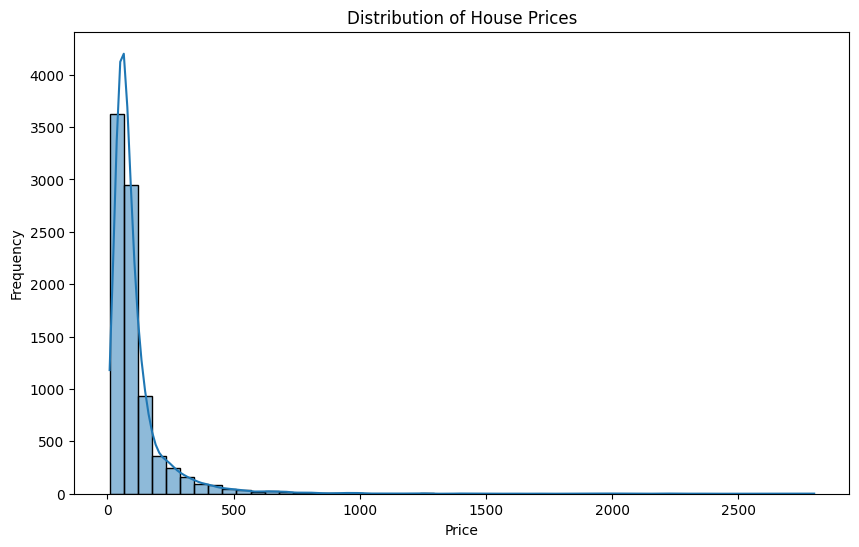

In [11]:
# check the price distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_final["price"], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [12]:
df_final["price"].skew()

np.float64(7.467726811504367)

In [13]:
df_final["price"].mean(), df_final["price"].median()

(np.float64(112.22776276276277), np.float64(72.0))

In [14]:
df_final[df_final["price"] > 1000].shape

(30, 13)

In [15]:
df_final['price'][df_final["price"] > 1000]

608     2800.0
902     1600.0
1761    1900.0
2094    2200.0
2249    2340.0
2597    1824.0
2891    1150.0
3476    2050.0
3725    2200.0
3860    1200.0
3882    2600.0
3928    1700.0
4204    1250.0
4546    1250.0
5053    1900.0
5107    1950.0
5679    1063.0
6224    2250.0
6252    2100.0
6425    1200.0
6508    2736.0
6887    1400.0
7257    2000.0
7494    2000.0
7717    1100.0
7980    1400.0
8096    1100.0
8103    1015.0
8244    1250.0
8268    1500.0
Name: price, dtype: float64

In [16]:
df_final.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Built-up Area,Ready To Move,Banjara Layout,2 Bedroom,NaN,1050,2.0,1.0,64.8,NaN,NaN,NaN,NaN
1,Super built-up Area,Ready To Move,Rajiv Nagar,3 BHK,PuoodSk,1690,3.0,1.0,125.0,NaN,NaN,NaN,NaN
2,Built-up Area,Ready To Move,Hebbal,2 BHK,NaN,1100,2.0,1.0,60.0,NaN,NaN,NaN,159.0
3,Plot Area,Ready To Move,Munnekollal,6 Bedroom,NaN,1200,4.0,2.0,110.0,NaN,NaN,NaN,8485.0
4,Built-up Area,18-Apr,Choodasandra,4 Bedroom,LGifeew,2429,3.0,1.0,210.0,NaN,NaN,NaN,8658.0


In [17]:
# Relationship between input features and target variable

df_final.groupby("area_type")["price"].mean().sort_values()

area_type
Carpet  Area             78.719746
Super built-up  Area     91.740163
Built-up  Area          103.350339
Plot  Area              212.278970
Name: price, dtype: float64

In [18]:
df_final.groupby("area_type")["price"].count().sort_values()

area_type
Carpet  Area              59
Plot  Area              1330
Built-up  Area          1536
Super built-up  Area    5733
Name: price, dtype: int64

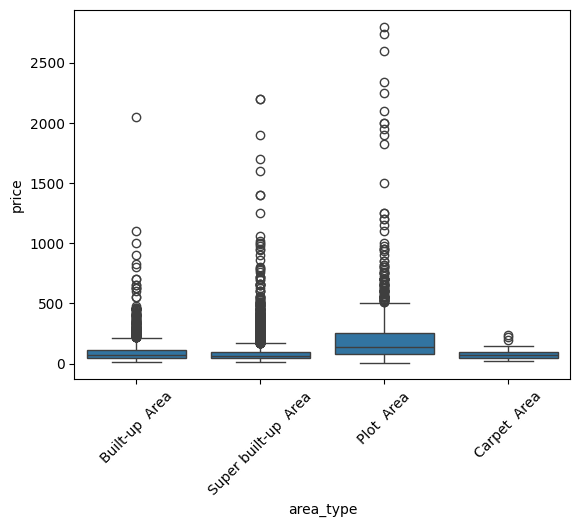

In [19]:
sns.boxplot(x="area_type", y="price", data=df_final)
plt.xticks(rotation=45)
plt.show()

In [20]:
df_final['location'].nunique()

1106

In [21]:
df_final['location'].value_counts().head(10)

location
Whitefield           342
Sarjapur  Road       267
Electronic City      193
Kanakpura Road       171
Thanisandra          156
Yelahanka            133
Hebbal               119
Uttarahalli          119
Marathahalli         111
Bannerghatta Road    106
Name: count, dtype: int64

In [22]:
location_counts = df_final['location'].value_counts()
print(location_counts.shape)
print(location_counts[location_counts <= 10].shape)
print(location_counts[location_counts > 10].shape)

(1106,)
(926,)
(180,)


In [23]:
df_final.groupby("location")["price"].median().sort_values(ascending=False).head(10)

location
Yemlur                 1900.0
Cubbon Road            1900.0
Church Street          1600.0
D Souza Layout         1015.0
Srinivas Colony         943.0
Binnamangala            900.0
Cunningham Road         800.0
Kathreguppe             725.0
Sector 4 HSR Layout     700.0
Rest House Road         690.0
Name: price, dtype: float64

In [24]:
df_final['size'].unique().shape

(29,)

In [25]:
df_final['size'].unique()

array(['2 Bedroom', '3 BHK', '2 BHK', '6 Bedroom', '4 Bedroom', '4 BHK',
       '5 Bedroom', '1 BHK', '3 Bedroom', '6 BHK', '7 Bedroom',
       '1 Bedroom', '7 BHK', '8 Bedroom', '5 BHK', '9 BHK', '10 Bedroom',
       '9 Bedroom', nan, '11 Bedroom', '43 Bedroom', '1 RK', '19 BHK',
       '27 BHK', '8 BHK', '16 BHK', '13 BHK', '12 Bedroom', '10 BHK'],
      dtype=object)

In [26]:
new_df_size = df_final['size'].str.extract(r'(\d+)')[0].astype(float)

#  check for values in new_df_size where size > 10
new_df_size[new_df_size > 9].shape

(17,)

In [27]:
new_df_size.value_counts()

0
2.0     3562
3.0     3170
4.0      921
1.0      444
5.0      222
6.0      149
7.0       67
8.0       57
9.0       35
10.0       9
11.0       2
43.0       1
19.0       1
27.0       1
16.0       1
13.0       1
12.0       1
Name: count, dtype: int64

In [28]:
new_df_size.unique(),new_df_size.unique().shape

(array([ 2.,  3.,  6.,  4.,  5.,  1.,  7.,  8.,  9., 10., nan, 11., 43.,
        19., 27., 16., 13., 12.]),
 (18,))

In [29]:
# group by size and get the median price on new_df_size

df_final.groupby(new_df_size)["price"].median()

0
1.0      34.5975
2.0      54.0000
3.0      88.0000
4.0     205.0000
5.0     177.5000
6.0     150.0000
7.0     150.0000
8.0     175.0000
9.0     200.0000
10.0    240.0000
11.0    160.0000
12.0    300.0000
13.0    275.0000
16.0    550.0000
19.0    490.0000
27.0    230.0000
43.0    660.0000
Name: price, dtype: float64

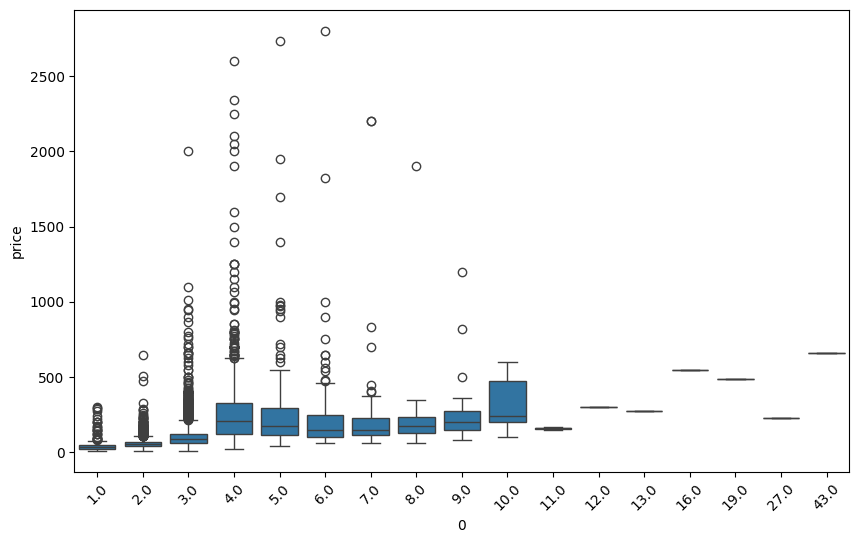

In [30]:
# boxplot for price vs new_df_size
plt.figure(figsize=(10, 6))
sns.boxplot(x=new_df_size, y=df_final["price"])
plt.xticks(rotation=45)
plt.show()

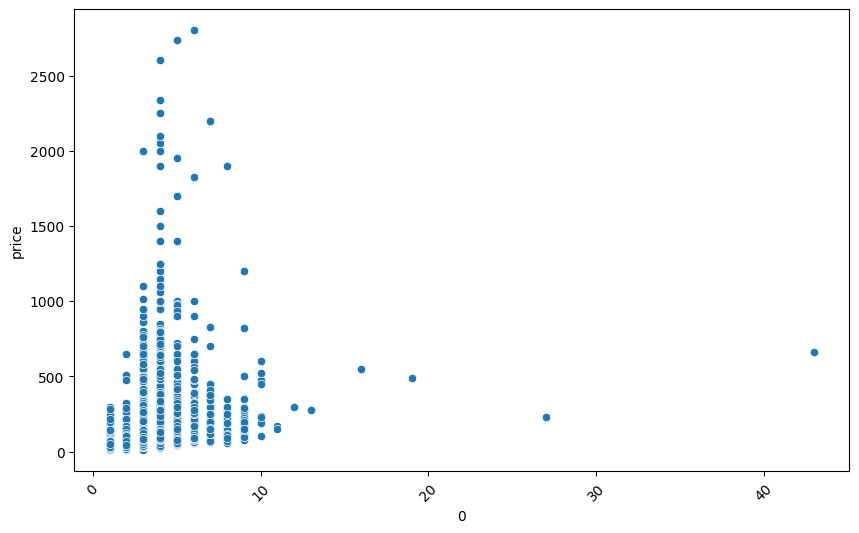

In [31]:
#  price vs new_df_size graph to check the relationship between price and size of the house to check if price increases with size of the house
plt.figure(figsize=(10, 6))
sns.scatterplot(x=new_df_size, y=df_final["price"])
plt.xticks(rotation=45)
plt.show()

In [32]:
# filtering new_data_size with bhk <= 10

new_df_size_10 = new_df_size[new_df_size <= 10]
new_df_size_10.shape

(8636,)

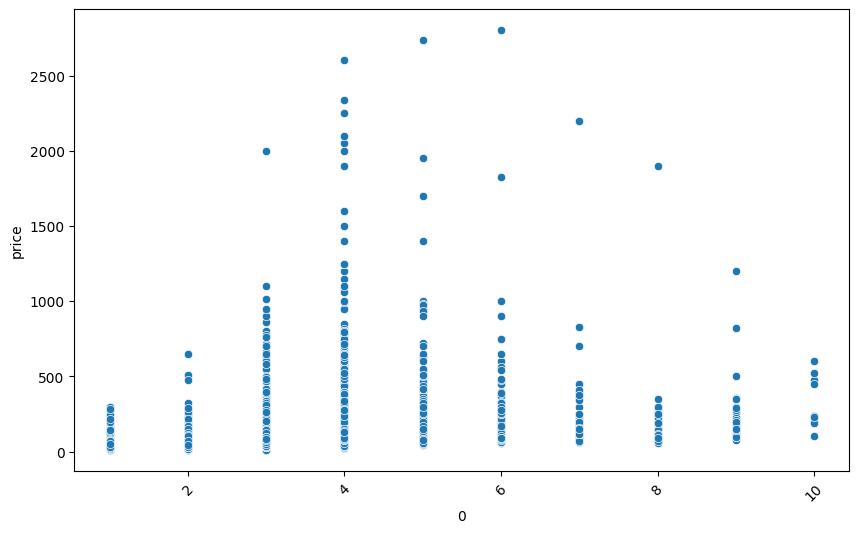

In [33]:
# now plot scatter plot for price vs new_df_size_10
plt.figure(figsize=(10, 6))
sns.scatterplot(x=new_df_size_10, y=df_final["price"])
plt.xticks(rotation=45)
plt.show()

In [34]:
df_final.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Built-up Area,Ready To Move,Banjara Layout,2 Bedroom,NaN,1050,2.0,1.0,64.8,NaN,NaN,NaN,NaN
1,Super built-up Area,Ready To Move,Rajiv Nagar,3 BHK,PuoodSk,1690,3.0,1.0,125.0,NaN,NaN,NaN,NaN
2,Built-up Area,Ready To Move,Hebbal,2 BHK,NaN,1100,2.0,1.0,60.0,NaN,NaN,NaN,159.0
3,Plot Area,Ready To Move,Munnekollal,6 Bedroom,NaN,1200,4.0,2.0,110.0,NaN,NaN,NaN,8485.0
4,Built-up Area,18-Apr,Choodasandra,4 Bedroom,LGifeew,2429,3.0,1.0,210.0,NaN,NaN,NaN,8658.0


In [35]:
df_final['total_sqft'].unique().shape

(1744,)

In [36]:
df_final['total_sqft'].value_counts().head(40)

total_sqft
1200    537
1100    149
2400    138
1500    127
600     119
1000    113
1300     85
900      83
1050     81
1350     81
1400     78
1250     76
1150     69
1800     69
2000     62
1600     62
1140     56
1020     51
1450     47
3000     45
800      44
1550     41
1180     41
950      41
1075     41
2500     39
1080     39
1255     38
1070     37
1220     37
1700     37
1160     37
1650     37
700      36
1125     35
1225     35
1260     35
4000     35
1175     31
1185     30
Name: count, dtype: int64

In [37]:
# sort the total_sqft column by ascending order
df_final['total_sqft'].sort_values(ascending=False)

1958          999
1318          998
4780          997
564           996
8403          996
          ...    
8295         1000
842          1000
3646         1000
4955    1.26Acres
7440            1
Name: total_sqft, Length: 8658, dtype: object

In [38]:
is_range = df_final['total_sqft'].astype(str).str.contains('-')
df_final[is_range].shape

(122, 13)

In [39]:
df_final['total_sqft'][is_range]

131     3630 - 3800
183     1255 - 1350
240       381 - 535
429      888 - 1290
552     1974 - 2171
           ...     
8332      527 - 639
8337    3508 - 4201
8519      520 - 645
8554    4260 - 4408
8591     840 - 1010
Name: total_sqft, Length: 122, dtype: object

In [ ]:
def convert_sqft_to_num(x):
    try:
        if '-' in x:
            tokens = x.split('-')
            if len(tokens) == 2:
                return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

In [41]:
df_final['new_sqft'] = df_final['total_sqft'].apply(convert_sqft_to_num)

In [42]:
df_final["new_sqft"].isnull().sum()

np.int64(31)

In [43]:
is_range = df_final['new_sqft'].astype(str).str.contains('-')
df_final[is_range].shape

(0, 14)

In [44]:
df_final['new_sqft'][is_range]

Series([], Name: new_sqft, dtype: float64)

In [45]:
df_final.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,new_sqft
0,Built-up Area,Ready To Move,Banjara Layout,2 Bedroom,NaN,1050,2.0,1.0,64.8,NaN,NaN,NaN,NaN,1050.0
1,Super built-up Area,Ready To Move,Rajiv Nagar,3 BHK,PuoodSk,1690,3.0,1.0,125.0,NaN,NaN,NaN,NaN,1690.0
2,Built-up Area,Ready To Move,Hebbal,2 BHK,NaN,1100,2.0,1.0,60.0,NaN,NaN,NaN,159.0,1100.0
3,Plot Area,Ready To Move,Munnekollal,6 Bedroom,NaN,1200,4.0,2.0,110.0,NaN,NaN,NaN,8485.0,1200.0
4,Built-up Area,18-Apr,Choodasandra,4 Bedroom,LGifeew,2429,3.0,1.0,210.0,NaN,NaN,NaN,8658.0,2429.0


In [46]:
# convert datatype of new_sqft to float
df_final['new_sqft'] = df_final['new_sqft'].astype(float)

In [47]:
type(df_final['new_sqft'][0])

numpy.float64

In [48]:
df_final['new_sqft'].sort_values(ascending=True)

7440     1.0
1989     5.0
3992    11.0
4355    15.0
5773    45.0
        ... 
6014     NaN
6457     NaN
7196     NaN
7253     NaN
7584     NaN
Name: new_sqft, Length: 8658, dtype: float64

In [49]:
df_final['new_sqft'].describe()

count     8627.000000
mean      1553.167129
std       1213.714950
min          1.000000
25%       1100.000000
50%       1277.000000
75%       1680.000000
max      52272.000000
Name: new_sqft, dtype: float64

In [58]:
df_final[df_final['new_sqft'] < 500].shape,df_final[df_final['new_sqft'] > 10000].shape, df_final[df_final['new_sqft'] > 7000].shape, df_final[df_final['new_sqft'] > 6000].shape

((82, 15), (20, 15), (34, 15), (48, 15))

In [60]:
df_final[df_final['new_sqft'] > 1700].shape,df_final[df_final['new_sqft'] > 6000].shape

((2051, 15), (48, 15))

In [61]:
df_final['new_sqft'].shape

(8658,)

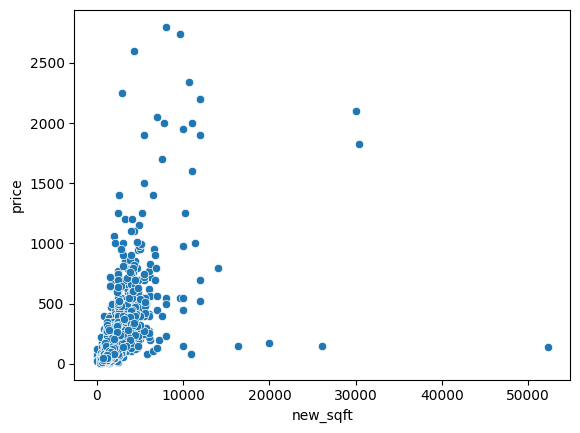

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="new_sqft", y="price", data=df_final)
plt.show()

In [57]:
df_final["price_per_sqft"] = (df_final["price"] * 100000) / df_final["new_sqft"]
df_final["price_per_sqft"].describe()

count    8.627000e+03
mean     8.443236e+03
std      1.317433e+05
min      2.678298e+02
25%      4.279643e+03
50%      5.457464e+03
75%      7.332005e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [65]:
df_final[df_final["price_per_sqft"] > 7500].shape,df_final[df_final["price_per_sqft"] > 10000].shape

((2017, 15), (1129, 15))

In [66]:
df_final.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,new_sqft,price_per_sqft
0,Built-up Area,Ready To Move,Banjara Layout,2 Bedroom,NaN,1050,2.0,1.0,64.8,NaN,NaN,NaN,NaN,1050.0,6171.428571
1,Super built-up Area,Ready To Move,Rajiv Nagar,3 BHK,PuoodSk,1690,3.0,1.0,125.0,NaN,NaN,NaN,NaN,1690.0,7396.449704
2,Built-up Area,Ready To Move,Hebbal,2 BHK,NaN,1100,2.0,1.0,60.0,NaN,NaN,NaN,159.0,1100.0,5454.545455
3,Plot Area,Ready To Move,Munnekollal,6 Bedroom,NaN,1200,4.0,2.0,110.0,NaN,NaN,NaN,8485.0,1200.0,9166.666667
4,Built-up Area,18-Apr,Choodasandra,4 Bedroom,LGifeew,2429,3.0,1.0,210.0,NaN,NaN,NaN,8658.0,2429.0,8645.533141


In [68]:
df_final['availability'].nunique()

76

In [69]:
df_final['availability'].unique()

array(['Ready To Move', '18-Apr', '21-Dec', '18-Mar', '18-Jul', '19-Aug',
       '18-Aug', '19-Dec', '21-Jul', '21-Jan', '18-Nov', '19-Mar',
       '19-Jan', '18-Dec', '19-Jun', '18-May', '18-Sep', '22-Jun',
       '18-Jun', '18-Jan', '17-Nov', '19-Oct', '20-Nov', '20-Jan',
       '20-Dec', '19-Jul', '18-Feb', '22-Nov', '19-Apr', '20-Sep',
       '15-Aug', '18-Oct', '21-May', '16-Dec', '21-Sep', '22-Dec',
       '17-Sep', '21-Jun', '21-Feb', '17-Aug', 'Immediate Possession',
       '19-Feb', '17-Oct', '19-May', '20-Jun', '16-Jan', '20-May',
       '22-Mar', '21-Oct', '20-Aug', '21-Mar', '17-Dec', '17-Jun',
       '17-May', '20-Jul', '21-Aug', '20-Apr', '16-Nov', '19-Sep',
       '22-Jan', '16-Mar', '17-Jul', '15-Oct', '19-Nov', '14-Nov',
       '17-Apr', '22-May', '16-Sep', '20-Feb', '20-Oct', '17-Feb',
       '14-Jul', '16-Jul', '17-Mar', '15-Nov', '17-Jan'], dtype=object)

In [73]:
df_final["availability"].value_counts()

availability
Ready To Move    6883
18-May            192
18-Dec            185
18-Apr            185
19-Dec            126
                 ... 
14-Jul              1
16-Jul              1
17-Mar              1
15-Nov              1
17-Jan              1
Name: count, Length: 76, dtype: int64

In [74]:
df_final["bath"].describe()

count    8611.000000
mean        2.693532
std         1.367290
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        40.000000
Name: bath, dtype: float64

In [75]:
df_final["bath"].value_counts()

bath
2.0     4464
3.0     2171
4.0      782
1.0      523
5.0      325
6.0      182
7.0       76
8.0       36
9.0       31
10.0       9
12.0       4
11.0       2
16.0       2
14.0       1
40.0       1
27.0       1
13.0       1
Name: count, dtype: int64

In [76]:
df_final[df_final["bath"] > 10].shape

(12, 15)

In [78]:
df_final["balcony"].describe()

count    8257.000000
mean        1.580235
std         0.812563
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: balcony, dtype: float64

In [79]:
df_final["balcony"].value_counts()

balcony
2.0    3340
1.0    3197
3.0    1057
0.0     663
Name: count, dtype: int64